<a href="https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/03_exploring_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌐 Exploring Interconnectivity and Events in Google Data Commons

**Part 3 of 3** in the [Google Data Commons Tutorial Series](https://github.com/Nastiiasaenko/Data-Commons-)  
Explore how to navigate and visualize relationships between real-world entities using the Knowledge Graph.

This notebook builds on the previous two tutorials:

📚 **Tutorial Series Overview**  
1. ✅ [Basics of Data Commons and Knowledge Graphs](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb)  
   Learn how to query the knowledge graph and explore metadata and relationships.  
2. 📈 [Building and Visualizing Emissions Datasets](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/02_environmental_exploration.ipynb)  
   Learn to retrieve and analyze time-series emissions data by state.  
3. 🌐 **[This Notebook] Interconnectivity and Event Exploration in GDC**  
   Learn to navigate relationships between places, events, and variables — and visualize these connections as graphs.



## 🔍 What You'll Learn in This Notebook

In this tutorial, we will use the Google Data Commons Knowledge Graph to:

✅ Explore how real-world entities (e.g., places, events) are connected via relationships  
✅ Use the `get_triples()` function to retrieve and traverse the graph  
✅ Build interactive visualizations of relationships using `networkx`  
✅ Identify types of events (e.g., fires, floods, cyclones) linked to a location  
✅ Trace connections across domains (e.g., how a single cyclone links multiple places)

You’ll also learn how to build reusable graph exploration tools and how to enhance your graphs with human-readable labels and classifications.

> This notebook assumes you've seen the core API methods like `get_property_values()` and `get_stat_series()`  
> — but key functions will be reintroduced where needed.


## 💡 Why Interconnectivity Matters in a Knowledge Graph

Unlike traditional databases, the **Google Data Commons Knowledge Graph** connects facts using entities and relationships.

This means:

- You can explore how a storm affected multiple places — and how those places relate to each other.
- You can link time series metrics to locations, events, or even organizations.
- You can create dynamic, traversable data structures — not just static tables.

> By the end of this notebook, you’ll be able to visually and programmatically explore how knowledge is structured and interconnected in Data Commons.


## 🛠 Setup: Install Packages and Import Libraries

This notebook uses several libraries to retrieve, analyze, and visualize entity relationships from the Data Commons knowledge graph.

You'll need:

- `datacommons` and `datacommons_pandas` to access and manipulate data
- `networkx` and `matplotlib` for graph visualization
- `random` and `pandas` for data wrangling

If you're running this notebook in Google Colab, the code block below will install all required packages.


## 🛠 Code Cell — Installation & Imports

In [1]:
# 📦 Installation (Google Colab only — uncomment if needed)
!apt-get install -y graphviz libgraphviz-dev pkg-config
!pip install datacommons datacommons_pandas pygraphviz

# 📚 Imports
import datacommons as dc
import datacommons_pandas as dcpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random

# 🖼️ Display settings
%config InlineBackend.figure_format = 'retina'


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
Suggested packages:
  gvfs
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin
  libgtk2.0-common libgvc6-plugins-gtk librsvg2-common libxdot4 pkg-config
0 upgraded, 10 newly installed, 2 to remove and 30 not upgraded.
Need to get 2,482 kB of archives.
After this operation, 7,671 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 pkg-config a

### 🧩 Optional Helper Cell — Pretty Printing Triples (Optional but useful later)

In [2]:
def print_sample_triples(triples, dcid, n=10, seed=42):
    """
    Randomly prints n triples for the given dcid.
    """
    random.seed(seed)
    sample = random.sample(triples[dcid], min(n, len(triples[dcid])))
    print(f"🔗 Sample Triples for {dcid}:\n")
    for s, p, o in sample:
        print(f"{s} — {p} → {o}")


## 🧠 Quick Recap: What You Should Know from Previous Tutorials

Before we dive into **entity interconnectivity**, let’s quickly revisit how Data Commons works — and why this tutorial focuses on relationships between entities.

> 💡 Don’t worry if you haven’t done Tutorials 1 or 2 — this notebook is self-contained and will reintroduce key methods as needed.

---

### 🧰 What is Data Commons?

**[Google Data Commons](https://datacommons.org/)** is a knowledge graph that brings together data from public sources like the U.S. Census, World Bank, EPA, and more — and links them together using shared identifiers and relationships.

Instead of just tables, Data Commons organizes facts as **entities** (like states, events, and variables) connected through **semantic relationships**. This lets you ask:  
> "Which events affected this place?" or  
> "What other entities are related to this school, region, or metric?"

---

### 📌 Core Concepts

- **DCIDs**: Every entity in Data Commons has a unique ID. For example:
  - `geoId/06` = California
  - `earthquakeEvent_2020_Alaska` = a specific earthquake
  - `Count_Person` = total population variable

- **Entities & Relationships**: These form a graph of information, where each fact looks like:

```css
[Event] — affectedPlace → [California] [California] — containedInPlace → [USA]

```


- This structure is called a **triple** — and it’s how all information is stored.

---

### 🔧 API Functions You Should Know

| Function | Purpose |
|---|---|
| `get_property_values(dcids, property)` | Retrieve static metadata (e.g., name, latitude, type) |
| `get_stat_series(place, variable)` | Get time-series data (e.g., emissions, population) |
| `get_places_in(dcids, place_type)` | Find nested places (e.g., counties within a state) |
| `get_triples(dcids)` | Retrieve all relationships (triples) for an entity |

You can also explore these entities interactively via:
- [📊 Statistical Variable Explorer](https://datacommons.org/tools/statvar)
- [🔍 Knowledge Graph Browser](https://datacommons.org/browser)

---

### 🔗 Why Interconnectivity?

While previous tutorials showed how to pull data on a single place or variable, **real-world insights often emerge from how entities relate to one another**.

In this tutorial, we’ll explore how:
- Events connect to multiple locations
- Places are part of overlapping administrative and geographic structures
- Relationships in the knowledge graph can reveal insights across time and space

> Understanding interconnectivity helps unlock multi-domain exploration — like finding environmental events that span states, or places that co-occur in shared contexts.



## 🧠 Code Cell — Example Recap Snippets

In [5]:
dcid = "geoId/06"  # California

# Fetch one property at a time
name = dc.get_property_values([dcid], 'name')
latitude = dc.get_property_values([dcid], 'latitude')
contained = dc.get_property_values([dcid], 'containedInPlace')

print("Name:", name[dcid][0])
print("Latitude:", latitude[dcid][0])
print("Contained in:", contained[dcid])


Name: California
Latitude: 37
Contained in: ['country/USA', 'usc/PacificDivision']


### 🧾 What Just Happened?

In the cell above, we queried the Knowledge Graph for information about **California** using its unique identifier (`geoId/06`).

We used the `get_property_values()` function to retrieve three pieces of static metadata:
- The human-readable **name** of the entity
- Its **latitude** (as a geographic coordinate)
- Its **hierarchical containment**, i.e., which regions it belongs to (`containedInPlace`)

These responses are returned as Python dictionaries, with the DCID as the key:
```python
{
  "geoId/06": {
    "name": ["California"],
    "latitude": [37],
    "containedInPlace": ["country/USA", "usc/PacificDivision"]
  }
}
```

This is the foundation of the **graph-based structure**: every place, event, or metric in Data Commons is a node, and they are linked by relationships like:

```css
California — containedInPlace → USA
California — affectedBy → [Cyclone, FireEvent, etc.]

```
We'll use these connections to build a visual graph of relationships in the next section.





# 📚 SECTION 1 — Exploring Entity Relationships Using Triples

## 📚 Exploring Relationships with Triples

In Tutorial 1, we used `get_triples()` to explore the connections between entities like California and its related events, organizations, or geographic features.

Now, we'll expand on that by:
- Sampling and classifying triples into relationship types
- Extracting and counting **predicates** (like `affectedPlace`, `containedInPlace`, `location`)
- Laying the foundation for deeper graph traversal later in this notebook

> If you're new to `get_triples()`, you can revisit [Tutorial 1 here](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb).


## ✅ Code Cell — Load Triples for a State and Sample

In [6]:
import datacommons as dc
import random

# Choose a state DCID
dcid = "geoId/51"  # Virginia

# Retrieve triples for the state
triples = dc.get_triples([dcid])

# Preview how many relationships we have
print(f"Total relationships for {dcid}: {len(triples[dcid])}")

# Sample a few for inspection
random.seed(42)
sampled_triples = random.sample(triples[dcid], 10)

# Print them nicely
for s, p, o in sampled_triples:
    print(f"{s} — {p} → {o}")


Total relationships for geoId/51: 4917
floodEvent/2015-07_0x89a5010000000000 — affectedPlace → geoId/51
coldTemperatureEvent/2022-01-08_geoId/5104595703 — affectedPlace → geoId/51
nces/510126000086 — containedInPlace → geoId/51
nces/510001002992 — containedInPlace → geoId/51
nces/01432109 — containedInPlace → geoId/51
geoId/5101190985 — containedInPlace → geoId/51
fireEvent/2024-01-14_0x8851db0000000000 — affectedPlace → geoId/51
stormEvent/nws5159692 — affectedPlace → geoId/51
fire/imsr1OClockFire20164412011 — location → geoId/51
wikidataId/Q14713117 — containedInPlace → geoId/51


Each line above is a "triple" in the Data Commons knowledge graph:

- **Subject**: The entity initiating the relationship (e.g., an event)
- **Predicate**: The relationship type (e.g., `affectedPlace`)
- **Object**: The target entity (e.g., Virginia)

Most of the time, you'll see:
- Events → `affectedPlace` → State
- Entities → `containedInPlace` → State
- Organizations or events → `location` → State

In the next step, we’ll classify all relationships for this state by **predicate type**.


## ✅ Code Cell — Count Predicate Types

In [7]:
from collections import Counter

# Count the predicate types across all triples
predicate_counts = Counter([p for _, p, _ in triples[dcid]])

# Display the top 10 most common
print("Top relationship types:")
for pred, count in predicate_counts.most_common(10):
    print(f"{pred}: {count}")


Top relationship types:
affectedPlace: 2966
containedInPlace: 1547
location: 219
nameWithLanguage: 100
nearbyPlaces: 20
overlapsWith: 15
latitude: 2
longitude: 2
typeOf: 2
member: 2


### 🧠 Interpreting Relationship Types in the Knowledge Graph

We just inspected the top relationship types (**predicates**) for Virginia in the Data Commons Knowledge Graph:

| Predicate        | Meaning                                                             |
|------------------|----------------------------------------------------------------------|
| `affectedPlace`   | The entity (often an event) affected this place (⚠️ often the most event-rich) |
| `containedInPlace` | This place belongs to a larger one (e.g., counties → Virginia → USA) |
| `location`         | General geospatial linkage (e.g., a school or company located in VA) |
| `nameWithLanguage` | Name of the entity tied to a specific language (e.g., English label) |
| `nearbyPlaces`     | Entities identified as geographically close                        |
| `overlapsWith`     | Entities with spatial or logical overlap                           |
| `latitude`, `longitude` | Simple geographic coordinates                                    |
| `typeOf`           | Identifies entity type/class (e.g., a region, a school, etc.)       |
| `member`           | Membership relations (e.g., counties part of a statistical region)  |

---

This tells us that **Virginia is the target** of many relationships:
- It’s affected by **~3,000 events**
- Contained **~1,500 other places**
- Has multiple layers of geographic and entity connections

These relationships form a **web of interconnectivity**, making Virginia a powerful example for exploring the graph.

> Next, we’ll zoom in on the most common one — `affectedPlace` — to analyze and visualize which **types of events** are connected to this state.


# 🔗 Section 2: Classifying and Visualizing Event Relationships

In this part, we'll build on the triple exploration by filtering event-related connections, grouping by event type, and visualizing the relationships.



## 🔗 Classifying and Visualizing Event Relationships

From our earlier triple exploration, we saw that `affectedPlace` was the most common relationship type — often indicating that **events** (e.g., hurricanes, wildfires, floods) impacted the state.

In this section, we'll:
- Filter triples that use `affectedPlace` as the predicate
- Extract the type of each event node (e.g., `fireEvent`, `stormEvent`)
- Count and visualize the number of events by type
- Begin constructing a **layered knowledge graph** centered on one state

> This lays the groundwork for showing how a single state is connected to hundreds of real-world events — and how those events, in turn, connect to other places.


## ✅ Code Cell — Filter Triples by affectedPlace Predicate

In [8]:
# Extract only the triples where the predicate is "affectedPlace"
affected_triples = [triple for triple in triples[dcid] if triple[1] == 'affectedPlace']

# Show how many we got
print(f"{len(affected_triples)} triples with 'affectedPlace' for {dcid}")


2966 triples with 'affectedPlace' for geoId/51


## ✅ Code Cell — Extract and Count Event Types

In [9]:
# Extract the 'subject' of each triple — usually an event DCID
event_entities = [s for s, p, o in affected_triples]

# Identify event types based on the prefix (before the slash or first underscore)
# Many events are like: fireEvent/abc123 or stormEvent_456
def classify_event_type(event_id):
    if '/' in event_id:
        return event_id.split('/')[0]
    elif '_' in event_id:
        return event_id.split('_')[0]
    return 'Unknown'

event_type_counts = Counter(classify_event_type(eid) for eid in event_entities)

# Preview the top event types
print("Most common event types affecting this state:")
for event_type, count in event_type_counts.most_common(10):
    print(f"{event_type}: {count}")


Most common event types affecting this state:
stormEvent: 2366
coldTemperatureEvent: 100
cyclone: 100
droughtEvent: 100
fireEvent: 100
floodEvent: 100
heatTemperatureEvent: 100


> 🔍 **What you're seeing above**:  
> We filtered all the triples where Virginia was the `affectedPlace`, then
> extracted the **subject** of each triple — which corresponds to the event
> entity.

From each event's DCID (e.g., `stormEvent/xyz123` or `fireEvent_abc789`), we parsed the **prefix** to determine its type — such as `stormEvent`, `floodEvent`, or `cyclone`.

The result: a count of how many events of each type are linked to the state.

This gives us a high-level view of which types of real-world incidents most frequently involve Virginia in the Data Commons Knowledge Graph.


## ✅ Optional Visualization — Plot Event Type Frequencies

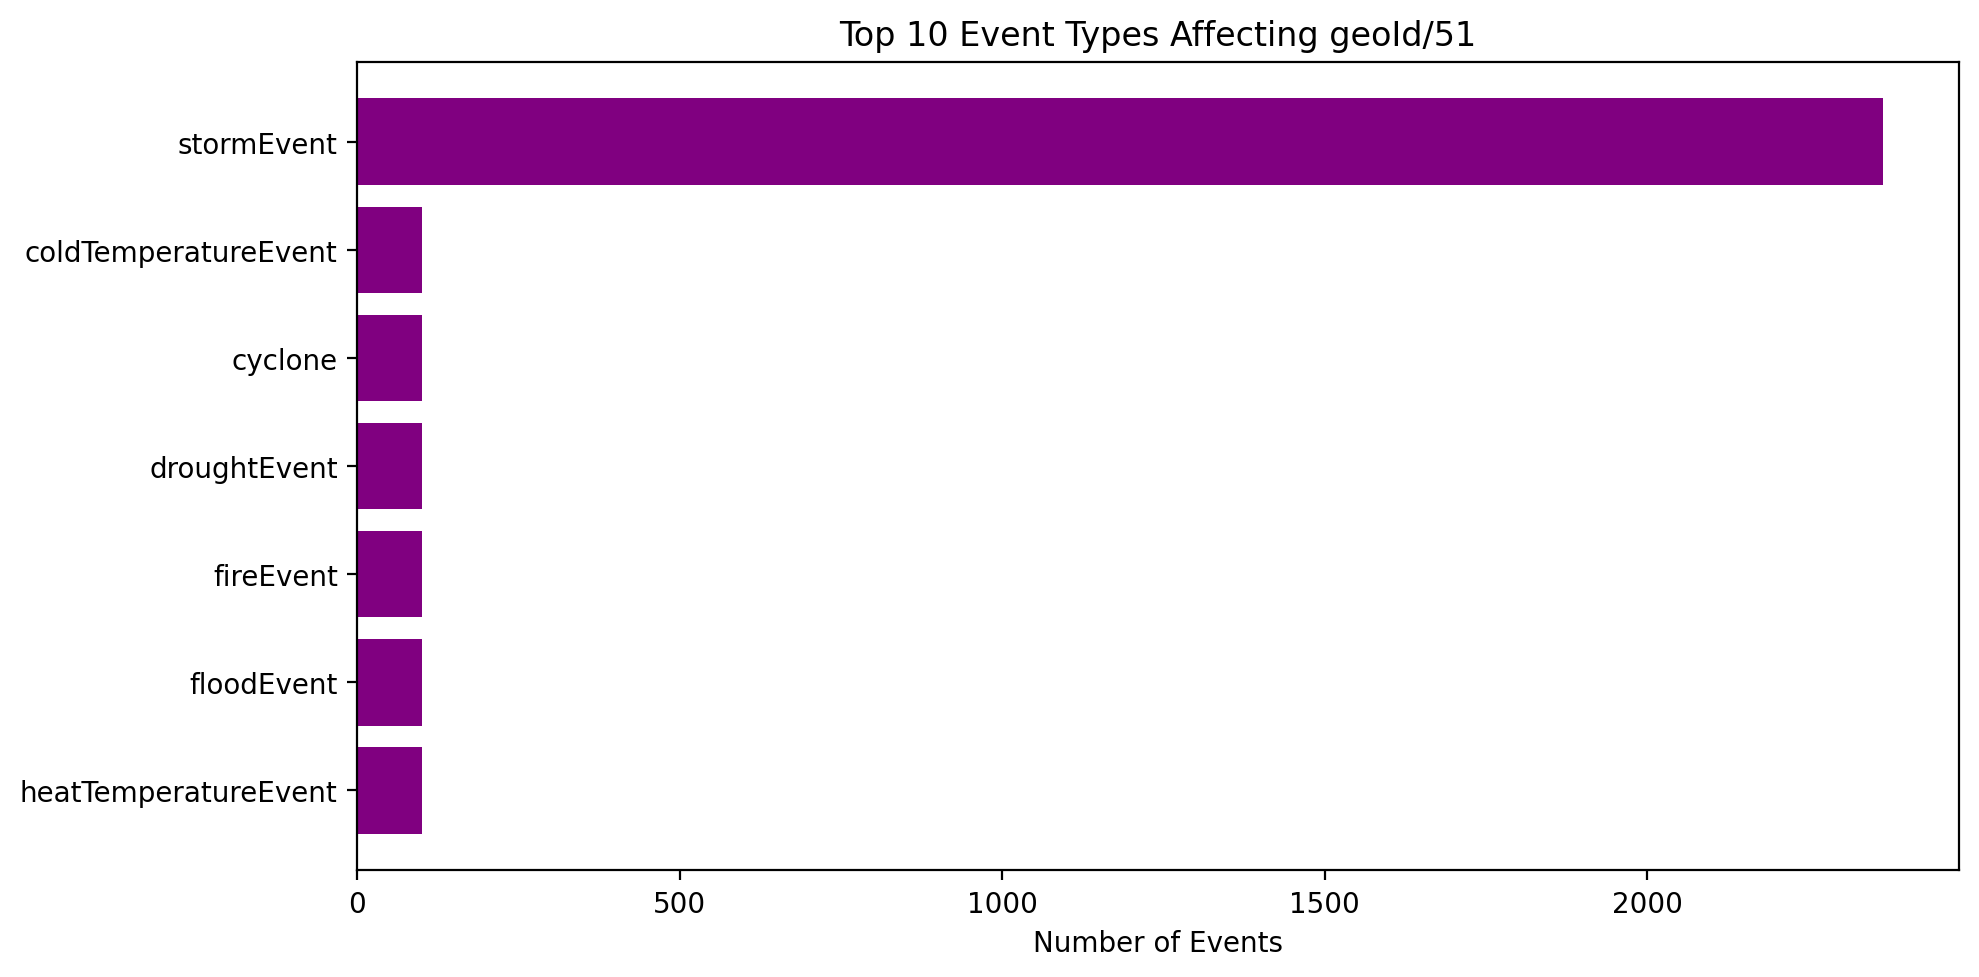

In [11]:
# Get human-readable state name (optional fallback)
try:
    state_name = name[dcid][0]
except:
    state_name = dcid  # fallback to DCID if name lookup fails

# Plot top event types
top_n = 10
event_types, counts = zip(*event_type_counts.most_common(top_n))

plt.figure(figsize=(10, 5))
plt.barh(event_types[::-1], counts[::-1], color="purple")
plt.xlabel("Number of Events")
plt.title(f"Top {top_n} Event Types Affecting {state_name}")
plt.tight_layout()
plt.show()


> 📊 **How to read this plot**:  
Each bar represents an **event type** (like `stormEvent` or `fireEvent`) that has impacted the selected state (Virginia in this case).  
The length of the bar shows how many **individual events** of that type are linked to the state in the Data Commons Knowledge Graph.

- `stormEvent` is by far the most common, with over 2,000 recorded links
- Other events like `floodEvent`, `cyclone`, and `fireEvent` are also present in smaller but equal counts (likely sampled subsets)

This gives us a clear sense of which types of incidents are most contextually connected to this state — and sets the stage for building a graph that maps these connections.


# 🌐 Section 3: Visualizing the State-to-Event Type Graph

## 🌐 Visualizing Event Relationships as a Graph

Now that we've classified the events affecting a state, we can begin turning this into a **structured graph**.

In this section, we'll:
- Represent the **state** as the center node
- Draw edges to each **event type**
- Size edges or annotate with the number of events of that type

This will give us our first layer of the knowledge graph — the **State → EventType** layer — from which we’ll later expand to individual events and other affected places.


## ✅ Code Cell — Generate and Plot a Simple Overall Knowledge Graph

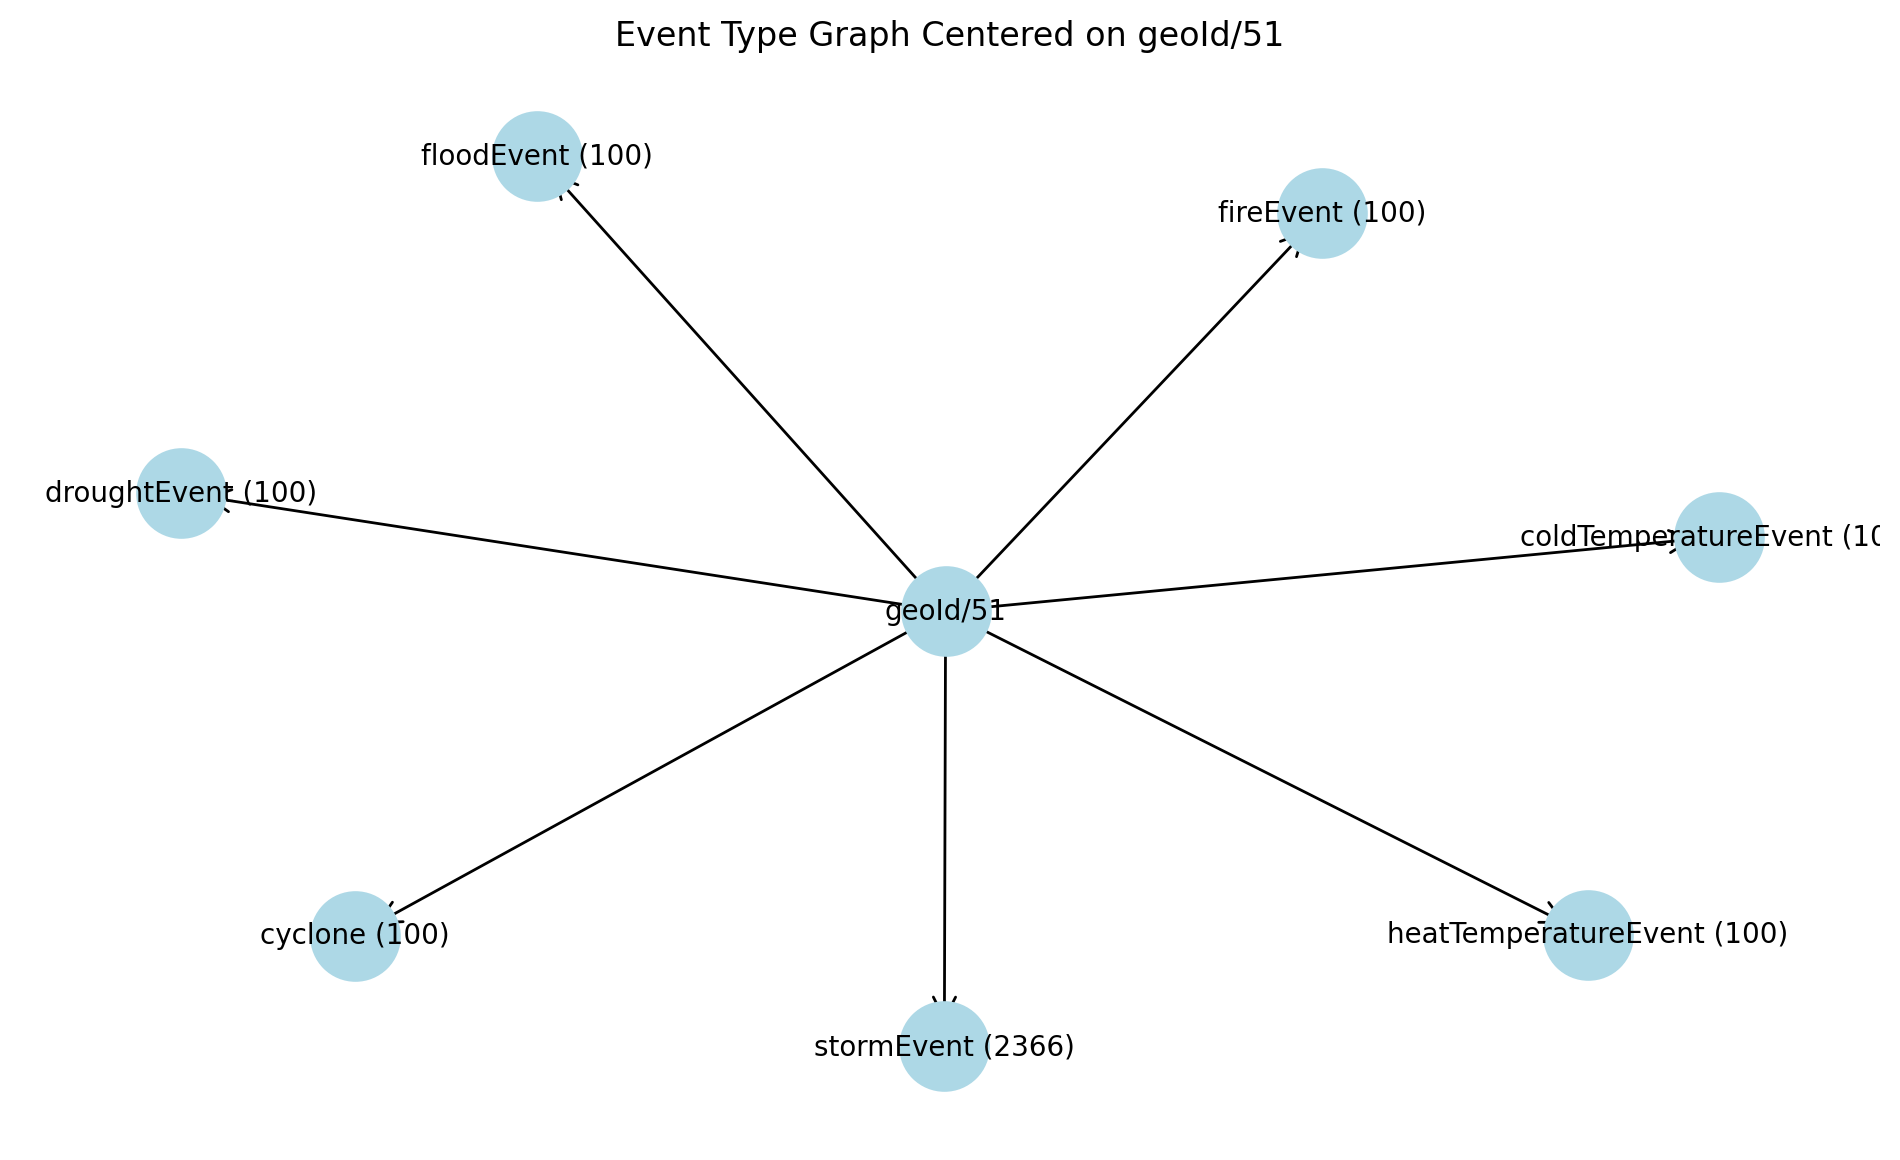

In [12]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add the state as the central node
G.add_node(dcid, label="State")

# Add each event type as a connected node
for event_type, count in event_type_counts.items():
    if count < 5:
        continue  # filter out rare types for clarity
    event_node = f"{event_type} ({count})"
    G.add_node(event_node, label="EventType")
    G.add_edge(dcid, event_node)

# Draw the graph
plt.figure(figsize=(12, 7))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1000)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title(f"Event Type Graph Centered on {state_name}")
plt.axis('off')
plt.show()


> 🧭 **How to interpret this graph**:
- The center node is the selected state (`geoId/51` → Virginia)
- Each surrounding node is an **event type**
- An arrow from the state to an event type means "this state is affected by events of this type"

In future steps, we’ll **expand these nodes further** — connecting them to individual events, and eventually, to **other places affected by the same events**.


# ✅ 🔄 Section 4: Sampling & Visualizing Real Triples

## 🔄 Sampling and Visualizing Real Triples

So far, we’ve grouped events by type and seen how often they affect our state. Now let’s look under the hood and **inspect real connections** that make up the Knowledge Graph.

Each triple is a simple statement of the form:

```
[Subject] — [Predicate] → [Object]
```


For example:

```
stormEvent/nws522670 → affectedPlace → geoId/51 (Virginia)

```


We'll sample a handful of triples from the full set for our chosen state and visualize them as a mini-graph.


## ✅ Code Cell — Sample and Print 15 Triples

In [13]:
# Sample 15 random triples for the chosen state
import random

random.seed(6)
sampled_triples = random.sample(triples[dcid], 15)

# Print the selected triples
for triple in sampled_triples:
    print(triple)


('stormEvent/nws5721671', 'affectedPlace', 'geoId/51')
('election/1978_S_VA00', 'location', 'geoId/51')
('stormEvent/nws2619', 'affectedPlace', 'geoId/51')
('nces/510030000132', 'containedInPlace', 'geoId/51')
('cyclone/ibtracs_1893268N12335', 'affectedPlace', 'geoId/51')
('geoId/51', 'area', 'SquareMile42775')
('geoId/5101991805', 'containedInPlace', 'geoId/51')
('wikidataId/Q14712562', 'containedInPlace', 'geoId/51')
('stormEvent/nws215534', 'affectedPlace', 'geoId/51')
('stormEvent/nws1048264', 'affectedPlace', 'geoId/51')
('stormEvent/nws1007007', 'affectedPlace', 'geoId/51')
('coldTemperatureEvent/2022-01-08_geoId/5100590878', 'affectedPlace', 'geoId/51')
('nces/510099000367', 'containedInPlace', 'geoId/51')
('stormEvent/nws280464', 'affectedPlace', 'geoId/51')
('heatTemperatureEvent/2022-01-01_geoId/5100991200', 'affectedPlace', 'geoId/51')


> 🔍 These triples show actual entity relationships involving our selected state.  
You'll notice a mix of event connections (`affectedPlace`), geographic containment (`containedInPlace`), and metadata (e.g., `location`, `nameWithLanguage`).

Now let’s visualize this mini-graph to see how these relationships appear structurally.


## ✅ Code Cell — Plot with networkx

We go through how to build and understand this graph extensively in Tutorial 1.

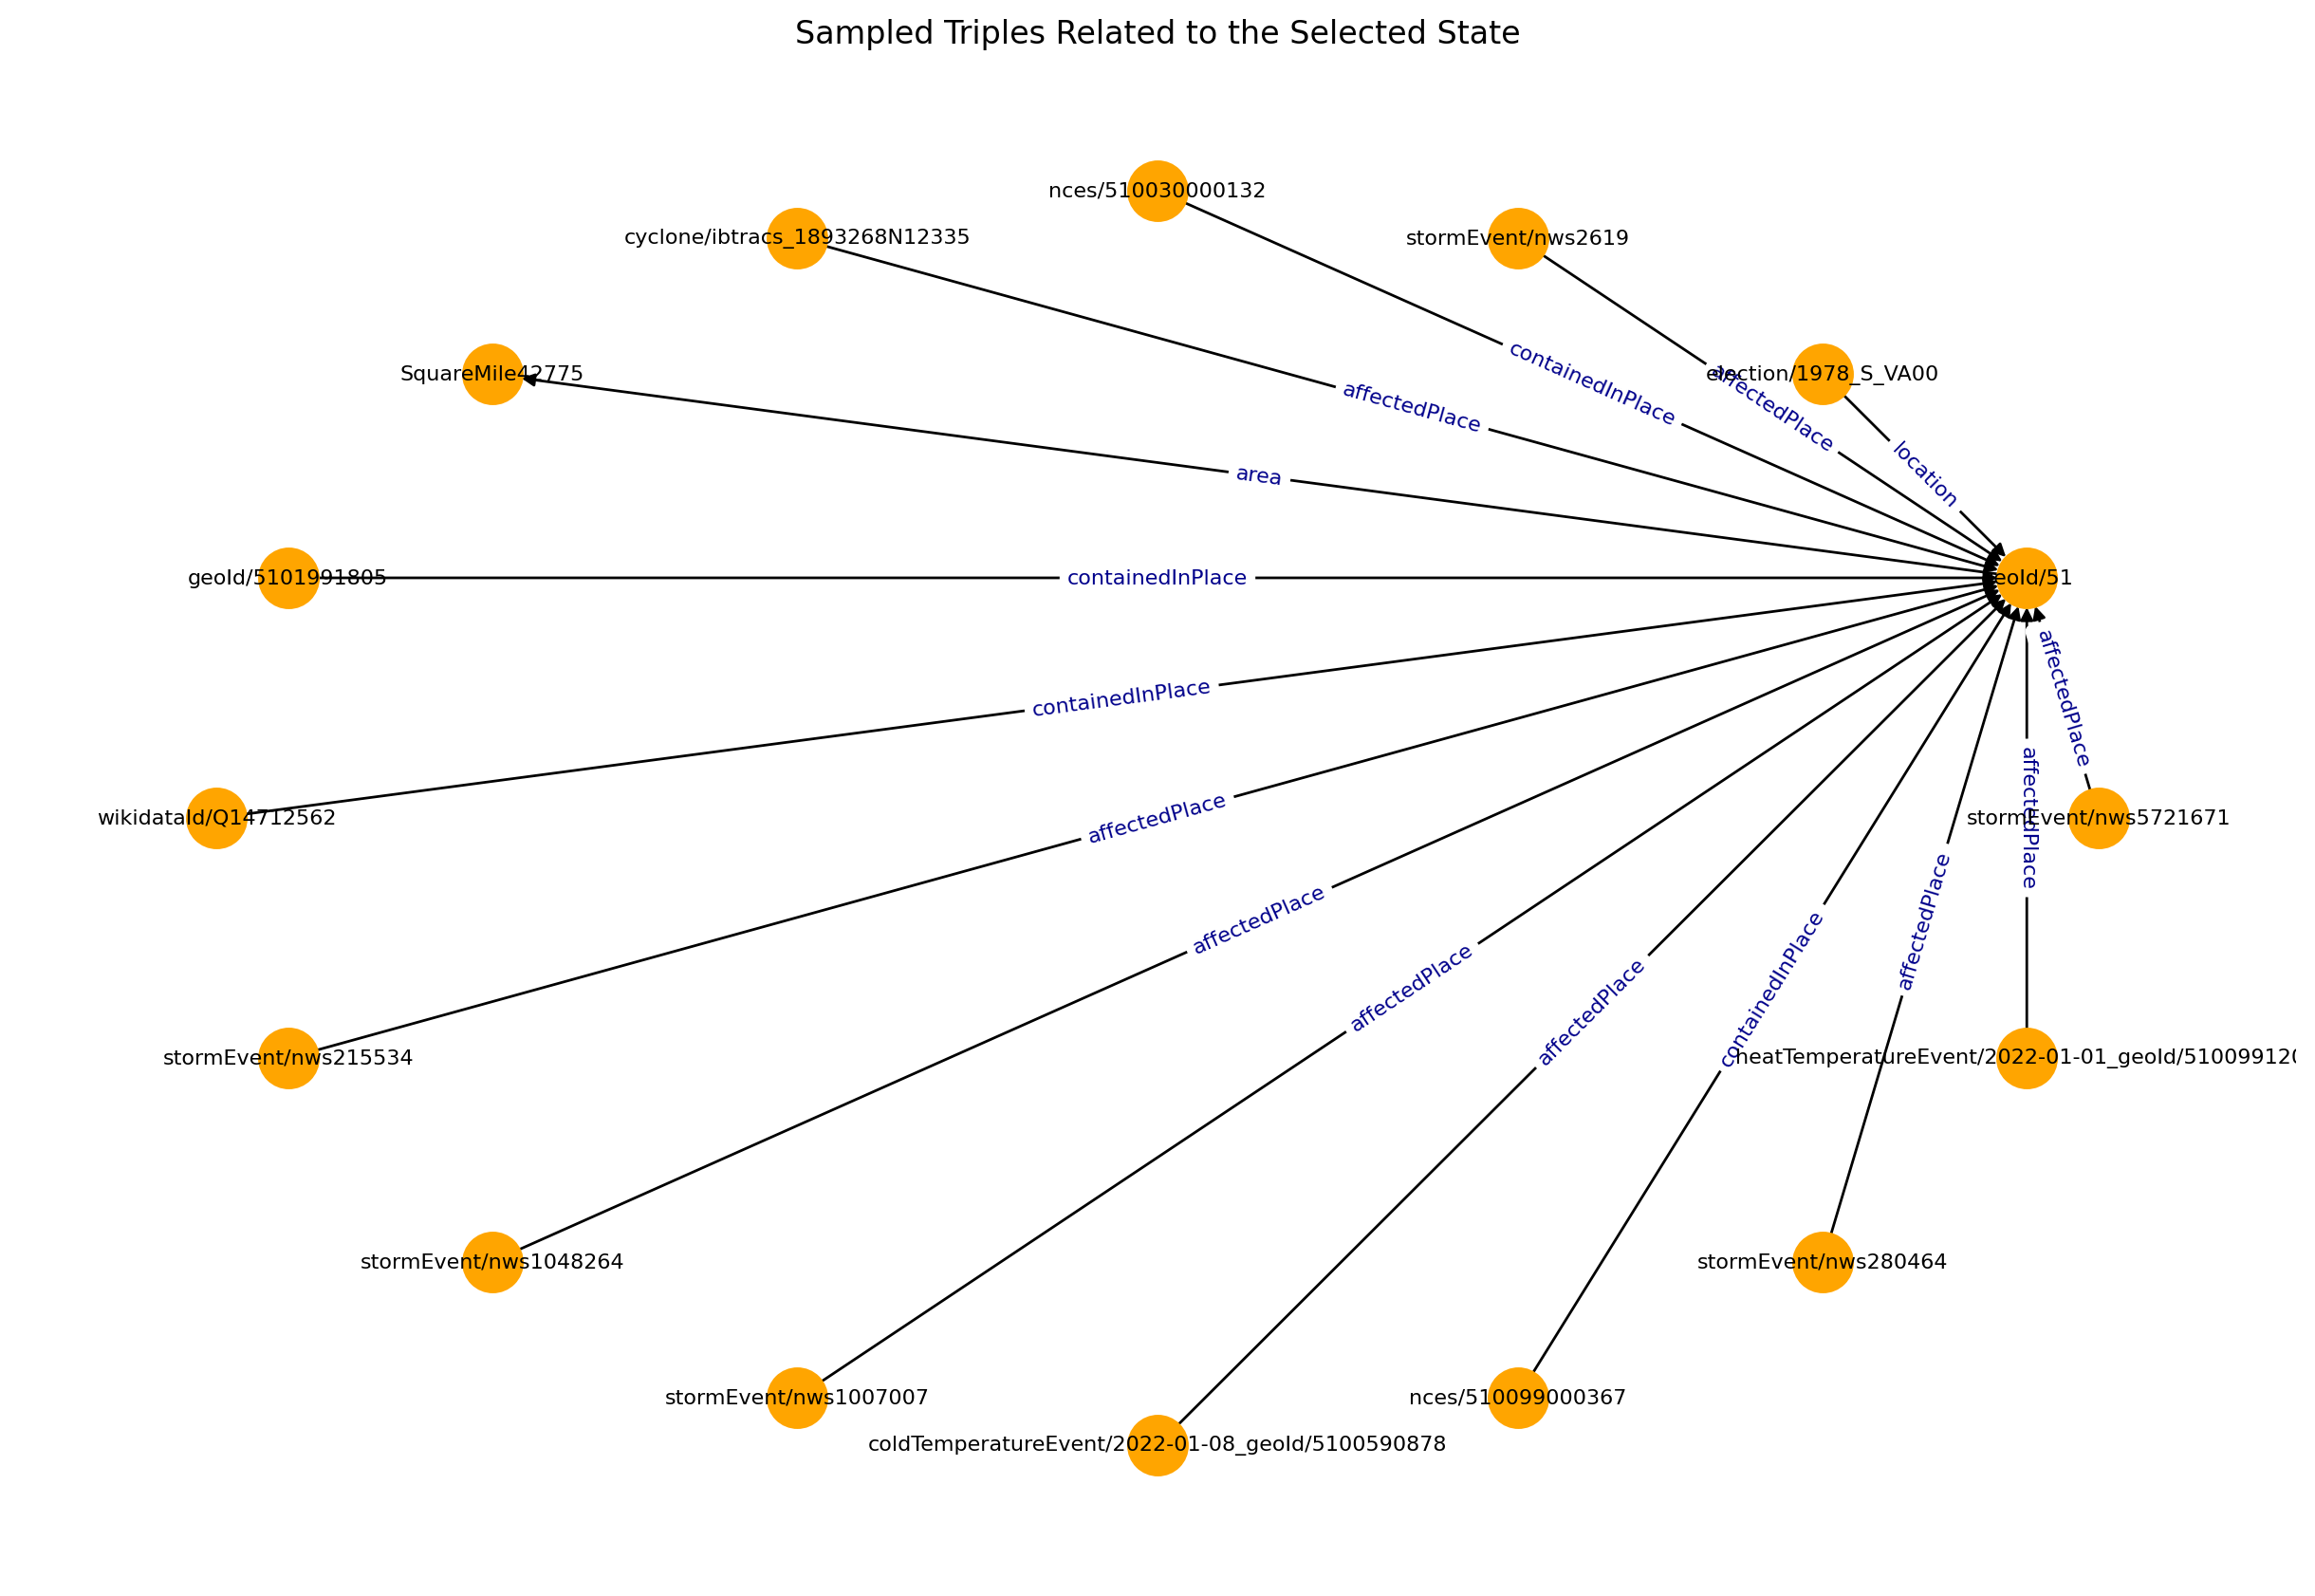

In [14]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges and label them by predicate
for s, p, o in sampled_triples:
    G.add_edge(s, o, label=p)

# Layout
plt.figure(figsize=(12, 8))
pos = nx.circular_layout(G)

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_color="orange", node_size=500, font_size=8)

# Draw edge labels (predicate)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='darkblue', font_size=8)

plt.title("Sampled Triples Related to the Selected State")
plt.axis("off")
plt.show()


> 🧠 This mini-graph shows how real events and places are tied to our selected state.

For example:
- An edge labeled `affectedPlace` shows an event that impacted the state
- An edge labeled `containedInPlace` links the state to a larger region (like the USA)
- `location`, `typeOf`, and `nameWithLanguage` help define metadata

But this is just a fragment. The full Knowledge Graph contains thousands of such edges — layered and linked. To understand it, we’ll use a conceptual flowchart next.


## 🧭 How the Knowledge Graph Captures Real-World Relationships

The mini-graph we just visualized shows how a state is linked to a variety of entities — but these aren’t just data points.  
They represent **real-world relationships**: a hurricane that impacted Virginia, a county that belongs to California, or the population of a rural region.

In the Data Commons Knowledge Graph (KG), every fact is stored as a **triple** — a subject, predicate, and object — that encodes how entities are connected.

For example:


```
stormEvent/nws123456 — affectedPlace → geoId/51 (Virginia) geoId/06 (California) — containedInPlace → country/USA geoId/17 (Illinois) — population → 12.8M


```



When visualized together, these triples form a web of meaning — a structure that **mirrors how things interact in the real world**.

The flowchart below illustrates this layered structure:

- **States** contain **counties**
- Each county has attributes like **population**, **area**, and **emissions**
- **Events** (like storms or fires) affect places at various levels

This design is what makes KG traversal so powerful — you can follow a storm to every region it touched, link emissions to the counties they came from, or trace the full impact of a disaster.

---

> 🗺️ You can try building this network for other states too:
- Florida: `geoId/12`  
- California: `geoId/06`  
- New York: `geoId/36`  
- Texas: `geoId/48`  
- ... *(see full list above)*

---

### 🔍 Conceptual Flowchart



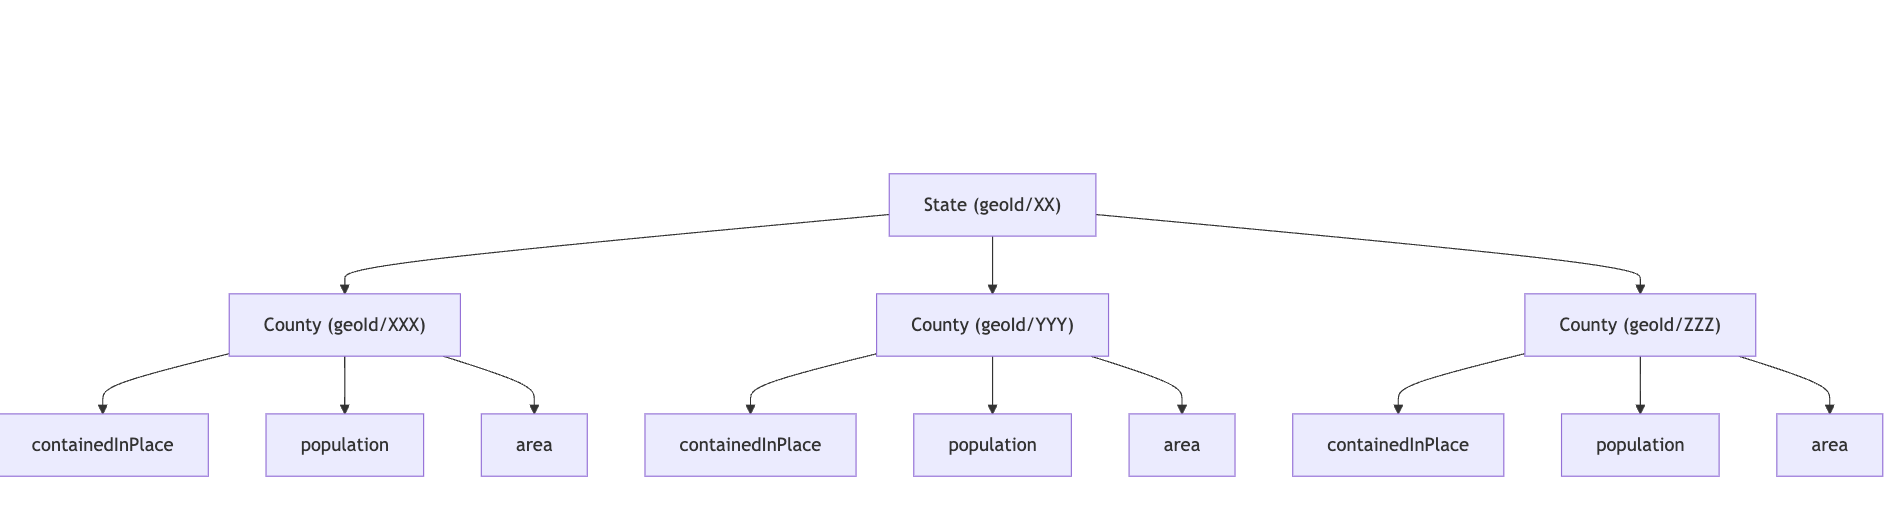









This flowchart illustrates:

- **Entity nodes**: States and counties
- **Predicate edges**: Relationships like `containedInPlace`, `population`, `area`
- **How information flows**: For example, a `stormEvent` affects a `County`, which is part of a `State`

> This structure mirrors what you just saw in your `networkx` graph. We’ll now **follow those edges** to uncover shared events and deeper interconnectivity.


# 🚀 SECTION 5: Building the Interconnectivity Graph


Now that we've visualized which types of events affect a state (e.g., Virginia), we’ll build a **deeper graph** that explores:

- Which **individual events** are tied to that state
- What **other places** those events also affected
- How these connections reflect **real-world interconnectivity**

This structure gives us a **State → Event → Affected Places** graph that spans multiple geographic and semantic layers.



## ✅ Code Cell — Step 1: Extract Sample Events for the State

In [19]:
# Step 1: Get sample events that affect the state
event_ids = [s for s, p, o in affected_triples if p == "affectedPlace"]

# Sample 5 events for illustration
random.seed(42)
sampled_events = random.sample(event_ids, 5)

# Preview the sampled events
for eid in sampled_events:
    print(f"Sampled event: {eid}")


Sampled event: stormEvent/nws5129656
Sampled event: floodEvent/2016-09_0x89b6b30000000000
Sampled event: cyclone/ibtracs_1856232N33285
Sampled event: stormEvent/nws10150862
Sampled event: stormEvent/nws10146388


> 🔍 In this step, we randomly selected 5 individual events that are connected to the state through the `affectedPlace` predicate.

These are actual entities in the Knowledge Graph — such as cyclones, storm events, or floods — and we’ll now explore what **other places** were also affected by these same events.


## ✅ Code Cell — Step 2: Retrieve Places Affected by Each Event

In [20]:
# Step 2: For each event, get all places it affected
event_place_map = {}

for eid in sampled_events:
    try:
        places = dc.get_property_values([eid], "affectedPlace")
        event_place_map[eid] = places.get(eid, [])
    except Exception as e:
        print(f"Error retrieving places for {eid}: {e}")


## ✅ Code Cell — Step 3: Preview Results



In [21]:
# Preview the results: event → affected places
for eid, places in event_place_map.items():
    print(f"\n🌀 Event: {eid}")
    if not places:
        print("   ⚠️ No affected places found.")
    for place in places:
        print(f"   📍 Affected Place: {place}")



🌀 Event: stormEvent/nws5129656
   📍 Affected Place: country/USA
   📍 Affected Place: geoId/51

🌀 Event: floodEvent/2016-09_0x89b6b30000000000
   📍 Affected Place: Earth
   📍 Affected Place: country/USA
   📍 Affected Place: geoId/51
   📍 Affected Place: geoId/51109
   📍 Affected Place: geoId/51177
   📍 Affected Place: northamerica
   📍 Affected Place: s2CellId/0x89b4010000000000
   📍 Affected Place: s2CellId/0x89b401fc00000000
   📍 Affected Place: s2CellId/0x89b6a84c00000000
   📍 Affected Place: s2CellId/0x89b6a90000000000
   📍 Affected Place: s2CellId/0x89b6a94c00000000
   📍 Affected Place: s2CellId/0x89b6ab0000000000
   📍 Affected Place: s2CellId/0x89b6abfc00000000
   📍 Affected Place: s2CellId/0x89b6ac1400000000
   📍 Affected Place: s2CellId/0x89b6ac3c00000000
   📍 Affected Place: s2CellId/0x89b6ac7c00000000
   📍 Affected Place: s2CellId/0x89b6ad0000000000
   📍 Affected Place: s2CellId/0x89b6ad0c00000000
   📍 Affected Place: s2CellId/0x89b6ad4c00000000
   📍 Affected Place: s2CellId/

> 🧠 Each event above is connected to **multiple geographic locations** — including counties, states, countries, or regions.

Some identifiers (like `geoId/...`) correspond to U.S. counties or states, while others (e.g., `s2CellId/...`) are geospatial grids or Census divisions.

This output reflects real-world scenarios where one storm, for example, may impact Virginia, North Carolina, and a collection of smaller counties.




## Section 5. 🧠 Visualizing the Interconnectivity Graph

Now let’s build a visual graph that connects:

- Your **state** (e.g., Virginia)
- The sampled **events** affecting that state
- All the **other places** those events also affected

To truly leverage the power of the Data Commons Knowledge Graph (KG), we need tools to go beyond static queries.

In this section, we'll build:

* A conceptual knowledge graph from scratch (starting with Virginia)

* A function to count and visualize event types

* A tool to interactively "walk" through connected nodes (e.g., from Virginia to events to other affected places)

* A complete interconnectivity graph using a custom class

> We will duplicate some steps we covered above briefly to build out the graph expansively


## 🧱 Step 5.1.1: Build a Simple Event Graph for a State

Let's begin with a lightweight version of a state-event graph: we’ll link a U.S. state to its top-level event types like `stormEvent`, `fireEvent`, etc., using the `affectedPlace` predicate.

In [23]:
import datacommons as dc
import networkx as nx
import matplotlib.pyplot as plt

def count_event_classes(triples):
    """
    Reads triples and returns a dictionary of event classes and their counts.
    """
    event_class_counts = {}
    for triple in triples:
        if triple[1] == "affectedPlace":
            event_class = triple[0].split("/")[0]
            event_class_counts[event_class] = event_class_counts.get(event_class, 0) + 1
    return event_class_counts


## 🔍 Step 5.1.2: Generate the Initial Graph (State → Event Types)

In [24]:
def generate_initial_state_graph(state_gcid):
    """
    Generates the initial portion of the state knowledge graph showing
    the state, 'affectedPlace', and event types with their counts
    """
    G = nx.DiGraph()
    triples = dc.get_triples([state_gcid])
    state_name = dc.get_property_values([state_gcid], prop='name')[state_gcid][0]
    G.add_node(state_name)

    affected_place_triples = [t for t in triples[state_gcid] if t[1] == "affectedPlace"]
    event_counts = count_event_classes(affected_place_triples)

    G.add_edge(state_name, "affectedPlace")
    for event_type, count in event_counts.items():
        G.add_edge("affectedPlace", f"{event_type} ({count})")

    return G


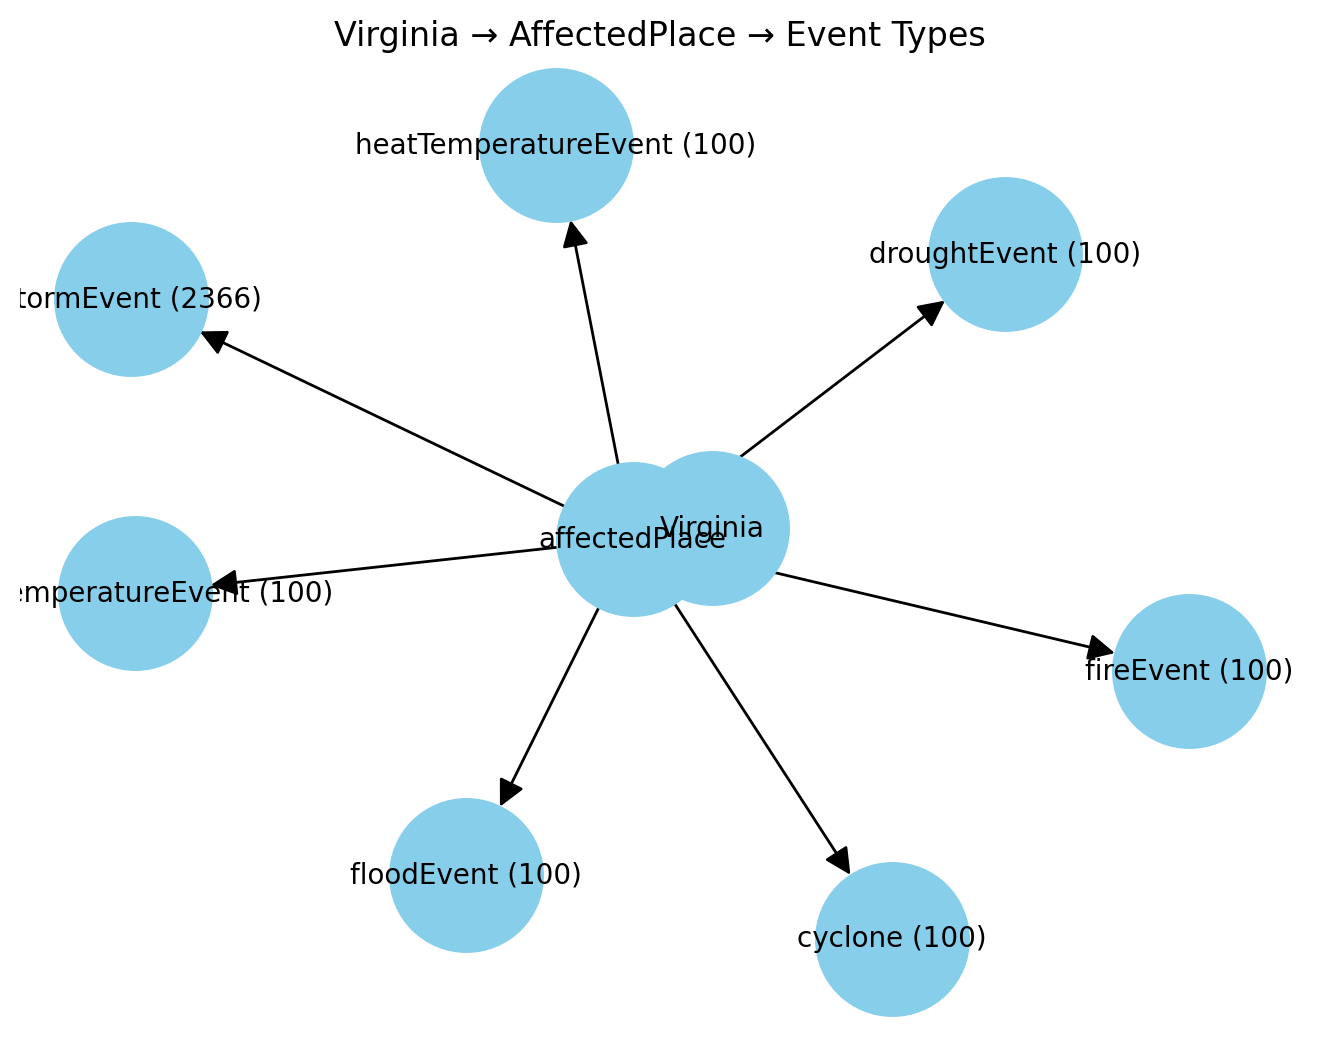

In [25]:
# Visualize Virginia's high-level event graph
state_graph = generate_initial_state_graph("geoId/51")  # Virginia
pos = nx.spring_layout(state_graph)
nx.draw(state_graph, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, arrowsize=20)
plt.title("Virginia → AffectedPlace → Event Types")
plt.show()


### 💡 What This Graph Shows

- Each event class node (e.g., `stormEvent`, `fireEvent`) represents a **category** of events that impacted the selected state (e.g., Virginia).
- The count in parentheses shows **how many individual events** of that type were recorded in the knowledge graph.
- This graph serves as a **top-level summary**, giving us a snapshot of event categories before we dive deeper into specific event instances and their interconnections.


## 🧭 Step 5.1.3: Explore Connected Events and Shared Affected Places

Let’s build a simple exploration tool to:

* Let the user choose an event type

* View which other entities are linked to the same events

* Reveal how real-world interconnectivity looks in the KG

In [26]:
import random

def explore_state_events(state_dcid):
    triples = dc.get_triples([state_dcid])
    event_types = {}

    for t in triples[state_dcid]:
        if t[1] == "affectedPlace":
            event_class = t[0].split("/")[0]
            event_types.setdefault(event_class, []).append(t[0])

    print("Event types that occurred in this state:")
    for i, e in enumerate(event_types):
        print(f"{i + 1}: {e}")

    choice = int(input("Choose an event type by number: ")) - 1
    selected_event_type = list(event_types)[choice]
    num = int(input(f"How many {selected_event_type} events to explore? "))
    selected_events = random.sample(event_types[selected_event_type], num)

    for ed in selected_events:
        event_name = dc.get_property_values([ed], prop='name')
        name = event_name[ed][0] if ed in event_name else "Unnamed"
        affected_triples = dc.get_triples([ed])[ed]
        places = [t[2] for t in affected_triples if t[1] == "affectedPlace"]
        names = dc.get_property_values(places, prop='name')
        print(f"\nEvent: {name}")
        for dcid, n in names.items():
            print(f" - Affected: {n[0]} ({dcid})")


In [27]:
# Example usage:
explore_state_events("geoId/51")


Event types that occurred in this state:
1: coldTemperatureEvent
2: cyclone
3: droughtEvent
4: fireEvent
5: floodEvent
6: heatTemperatureEvent
7: stormEvent
Choose an event type by number: 4
How many fireEvent events to explore? 10

Event: FireEvent at Sussex County on 2024-01-14
 - Affected: World (Earth)
 - Affected: United States (country/USA)
 - Affected: Virginia (geoId/51)
 - Affected: Sussex County (geoId/51183)
 - Affected: North America (northamerica)
 - Affected: L10 S2 Cell 0x89b04d0000000000 (s2CellId/0x89b04d0000000000)
 - Affected: South Atlantic Division (usc/SouthAtlanticDivision)
 - Affected: South Region (usc/SouthRegion)

Event: FireEvent at Grayson County on 2024-01-08
 - Affected: World (Earth)
 - Affected: United States (country/USA)
 - Affected: Virginia (geoId/51)
 - Affected: Grayson County (geoId/51077)
 - Affected: North America (northamerica)
 - Affected: L10 S2 Cell 0x8851c30000000000 (s2CellId/0x8851c30000000000)
 - Affected: South Atlantic Division (usc/S

---

### 🔍 Exploring Specific Event Instances and Their Affected Locations

Now that we've seen how to retrieve and count **event types** associated with a state, we can go a step deeper and **explore specific instances** of those events — and more importantly, see which locations they’ve affected.

The function `explore_state_events(state_dcid)` does the following:

1. **Retrieves all triples** for the selected state (e.g., `geoId/51` for Virginia).
2. **Extracts and groups events** by event type (`fireEvent`, `cyclone`, etc.).
3. **Prompts you** to:
   - Select one event type to explore.
   - Choose how many events of that type you’d like to inspect.
4. For each selected event, the function:
   - Retrieves the event’s **name** (if available).
   - Retrieves all **locations affected** by that event.
   - Looks up the **human-readable names** of those locations.
   - Displays a summary of the event and where it had an impact.

---

### ✅ Sample Output

```css
Event types that occurred in this state:
1: coldTemperatureEvent
2: cyclone
3: droughtEvent
4: fireEvent
5: floodEvent
6: heatTemperatureEvent
7: stormEvent
Choose an event type by number: 4
How many fireEvent events to explore? 10


```

After choosing fireEvent, we see a breakdown of individual fire events and the places they affected:

```css
Event: FireEvent at Sussex County on 2024-01-14
 - Affected: World (Earth)
 - Affected: United States (country/USA)
 - Affected: Virginia (geoId/51)
 - Affected: Sussex County (geoId/51183)
 - Affected: North America (northamerica)
 - Affected: L10 S2 Cell 0x89b04d0000000000
 - Affected: South Atlantic Division (usc/SouthAtlanticDivision)
 - Affected: South Region (usc/SouthRegion)

Event: FireEvent at Grayson County on 2024-01-08
 - Affected: World (Earth)
 - Affected: United States (country/USA)
 ...


```


---

### 🧠 Why This Matters

This is where the **interconnectivity** of the Knowledge Graph (KG) truly shines.

- A single **event** (like a `fireEvent`) is tied to **multiple geographic entities** — from specific counties and states to broader regions such as _North America_, the _United States_, or spatial identifiers like _S2 cells_.

- This architecture enables **multi-scale traversal**: you can "walk the graph" from a local area (e.g., `geoId/51183` for Sussex County) up to national, continental, or even global contexts — all using the same structured logic.

- Many events also **serve as bridges between different places**: for example, one storm or fire might impact Virginia **and** North Carolina **and** a federal division — meaning you can trace how different regions are connected via shared experiences or events.

These small explorations lead us into our final goal for this tutorial — to **programmatically build and visualize the entire interconnectivity network** around a state and its event history using structured code and graph tools.

---


# 🔧 Next: Building a Full Interconnected Graph Programmatically (Class-based graph construction)


## 🧱 From Exploration to Construction

Now that we’ve **explored** real events and how they connect a state to many other entities (like counties, regions, and cells), it’s time to **systematically recreate** that interconnectivity using loops and class-based design.

Before we dive into the code, here’s a **conceptual map** of what we want to construct:



## Creating a programmatic way to connect entities in loops

For this objective we will try to recreate this relationship flow

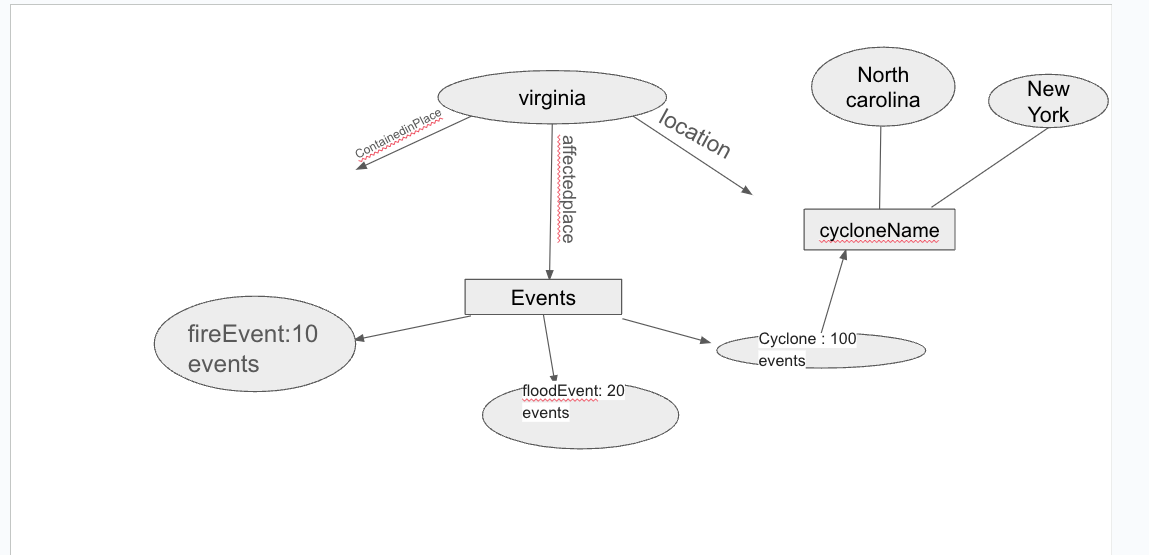



This schematic illustrates the structure we’re aiming to build:

- A state like **Virginia** is:
  - linked to events via `affectedPlace`
  - connected to a **specific event class** like `cyclone`, `floodEvent`, or `fireEvent`
  - further tied to other locations **through shared events** like a named `cyclone`

---

## 🛠️ Creating a Programmatic Way to Connect Entities in Loops

To recreate this relationship flow, we’ll use a class-based Python structure that:
- Initializes with a state
- Loops through relevant event types
- Connects them to other affected places
- Adds higher-level edges like event class and named events

Let’s walk through this architecture step by step.


# 🧩 Section 5.2: Building the Interconnected Graph with Class-Based Architecture

## 🧩 SECTION 4 — Building the Interconnected Knowledge Graph

### 🛠️ Objective

Now that we’ve explored individual event relationships and conceptually mapped how a state interacts with different entities (like counties, cyclones, and other states), let’s build a **reusable class** that automates this process for any U.S. state.

We’ll use the **Google Data Commons API** and **NetworkX** to:
- Fetch a state's event relationships
- Connect entities using clean, filtered predicates (`affectedPlace`, `containedInPlace`, `location`)
- Trace relationships from the state to events → to other locations → to shared entities (like cyclones)
- Visualize it all in a clear, readable graph

> This mirrors our earlier conceptual graph and turns it into a **programmatic, scalable pipeline**.


## 📦 Step 5.2.1: Create the class skeleton

In [28]:
# 📦 Step 1: Create the class skeleton

import datacommons as dc
import networkx as nx
import matplotlib.pyplot as plt

class StateKnowledgeGraph:
    def __init__(self, state_dcid):
        """
        Initialize the knowledge graph object with a specific U.S. state.

        Args:
            state_dcid (str): The DCID of the state (e.g., "geoId/51" for Virginia)
        """
        self.state_dcid = state_dcid
        self.state_name = self.get_state_name()
        self.triples = self.get_state_triples()
        self.graph = nx.DiGraph()


### 🔍 What’s Happening Here?

- `state_dcid`: is the unique ID used in the Data Commons Graph (e.g., `geoId/51` for Virginia)
- `self.state_name`: retrieves a readable name using `dc.get_property_values`
- `self.triples`: stores all relationships connected to the state (triples = subject, predicate, object)
- `self.graph`: initializes a blank NetworkX graph that we’ll fill in

---

We'll build up each method and graph drawing logic in the next steps.


## 🧱 Step 5.2.2: Fetching State Metadata

Next, we define the helper methods to:
- Retrieve all triples (facts) about the state
- Get a human-readable name for the DCID

In [29]:
    def get_state_triples(self):
        """Retrieve all triples (facts) for the given state."""
        return dc.get_triples([self.state_dcid])

    def get_state_name(self):
        """Retrieve the state name using its DCID."""
        name = dc.get_property_values([self.state_dcid], prop='name')
        return name[self.state_dcid][0] if self.state_dcid in name else self.state_dcid


### 📌 Notes:
- `dc.get_triples()` returns a dictionary of triples in the format:  
  `(subject, predicate, object)` — all connected to the state
- `get_property_values(..., prop='name')` pulls readable names from DCIDs like `geoId/51 → Virginia`


## 🧱 Step 5.2.3: Filter Relevant Predicate Relationships



Not all relationships are equally useful when building a geographic or event-based graph.

We’ll now filter the state’s triples to include only the most meaningful ones for interconnectivity:
- `affectedPlace`: events that impacted this location
- `containedInPlace`: geographic containment (e.g., counties → state)
- `location`: general location links (e.g., organizations, events, etc.)


In [30]:
def filter_predicates(self):
        """Filter to keep only relevant semantic relationships."""
        relevant_predicates = {"affectedPlace", "containedInPlace", "location"}
        return [triple for triple in self.triples[self.state_dcid] if triple[1] in relevant_predicates]


### 📌 Example Output:
This will return triples like:

```
('stormEvent/nws1007007', 'affectedPlace', 'geoId/51') ('nces/510126000086', 'containedInPlace', 'geoId/51') ('fire/imsr1OClockFire20164412011', 'location', 'geoId/51')
```


These are the connections we’ll use to build and draw the actual knowledge graph in the next steps.


## 🧱 Step 5.2.4: Count Event Classes Affecting the State

In this step, we’ll extract all events that **affect the state** and classify them by **event type**.

For example, we want to go from:
```
fireEvent/2023_abc → affectedPlace → geoId/51 cyclone/ibtracs_xyz → affectedPlace → geoId/51
```
to

```
{ 'fireEvent': 74, 'cyclone': 15, 'stormEvent': 289 }
```


In [32]:
def count_event_classes(self):
        """
        Count how many times each event class appears as affecting the state.
        """
        event_class_counts = {}
        for triple in self.triples[self.state_dcid]:
            if triple[1] == "affectedPlace":
                event_class = triple[0].split("/")[0]
                event_class_counts[event_class] = event_class_counts.get(event_class, 0) + 1
        return event_class_counts


### 🔍 Why This Matters:
- Helps you visualize and label connections in the graph (e.g., “fireEvent (74)”)
- Enables later filtering (e.g., “only show cyclone-related events”)
- Prepares us to show event types in the final graph layout


## 🌀 Step 5.2.5: Cyclone-Specific Exploration (Optional)

We’ll now add methods to:
- Filter all triples related to **cyclone events**
- Get the **human-readable name** of a cyclone
- Get all **locations affected** by that specific cyclone

This lets us overlay cyclone data


In [33]:
def filter_cyclone_triples(self):
        """Filter triples to include only those related to cyclones."""
        return [triple for triple in self.triples[self.state_dcid] if 'cyclone' in triple[0]]

def get_cyclone_name(self, cyclone_dcid):
        """Get the name of a specific cyclone (e.g., Hurricane Sandy)."""
        name = dc.get_property_values([cyclone_dcid], prop='name')
        return name[cyclone_dcid][0] if cyclone_dcid in name else cyclone_dcid

def get_affected_places(self, cyclone_dcid):
        """Get a dictionary of place DCIDs and names affected by a given cyclone."""
        triples_cyclone = dc.get_triples([cyclone_dcid])
        affected = [triple for triple in triples_cyclone[cyclone_dcid] if triple[1] == "affectedPlace"]
        place_ids = [triple[2] for triple in affected]
        return dc.get_property_values(place_ids, 'name')






### 🔎 Example Use Case:
These functions let us show a cyclone node → connected to the counties, states, and regions it affected — often across multiple states.

We’ll use this in our graph-building logic next.


## 🧱 Step 5.2.6: Drawing the Full Knowledge Graph

Now that we’ve collected triples, filtered relationships, and optionally explored cyclones, we’re ready to render the graph!

The `draw_graph()` method:
- Adds the **state node**
- Adds edges from the state to all relevant entities
- Adds a layer of **event classes** connected to `"affectedPlace"`
- If provided, overlays a **specific cyclone** and all its affected locations


In [34]:
    def draw_graph(self, cyclone_dcid=None):
        """Draw the knowledge graph using NetworkX and matplotlib."""

        # Add the initial state node
        self.graph.add_node(self.state_name)

        # Add edges from the state to relevant entities
        filtered_triples = self.filter_predicates()
        for s, p, o in filtered_triples:
            self.graph.add_node(o)
            self.graph.add_edge(self.state_name, o, label=p)

        # Add event class layer (e.g., stormEvent, cyclone, fireEvent)
        event_class_counts = self.count_event_classes()
        self.graph.add_node("affectedPlace")
        self.graph.add_edge(self.state_name, "affectedPlace")

        for event_class in event_class_counts:
            self.graph.add_node(event_class)
            self.graph.add_edge("affectedPlace", event_class)

        # Optional: Add a cyclone subgraph
        if cyclone_dcid:
            cyclone_name = self.get_cyclone_name(cyclone_dcid)
            self.graph.add_node(cyclone_name)
            self.graph.add_edge("cyclone", cyclone_name)

            affected_places = self.get_affected_places(cyclone_dcid)
            for place_dcid, name_list in affected_places.items():
                place_name = name_list[0] if name_list else place_dcid
                self.graph.add_node(place_name)
                self.graph.add_edge(cyclone_name, place_name)

        # Draw the graph
        plt.figure(figsize=(15, 10))
        pos = nx.spring_layout(self.graph, k=3, iterations=100)
        nx.draw(self.graph, pos, with_labels=True, arrows=True,
                node_size=1000, node_color="skyblue", font_size=12)
        edge_labels = nx.get_edge_attributes(self.graph, 'label')
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels,
                                     font_color='red', font_size=10)
        plt.title(f"Knowledge Graph for {self.state_name}")
        plt.axis('off')
        plt.show()


### ✅ Example Usage

```python
state_kg = StateKnowledgeGraph("geoId/51")  # Virginia
state_kg.draw_graph(cyclone_dcid="cyclone/ibtracs_2008241N19303")
```

🧠 What You See:

* The main state is at the center

* It's connected to its event classes, contained entities, or location-linked events

* Optional: If a cyclone is provided, it shows how that event links multiple regions



# ✅ Final Tutorial Code Block: Interactive Graph Construction & Visualization

So now let's wrap up all the elements we discussed into one class.

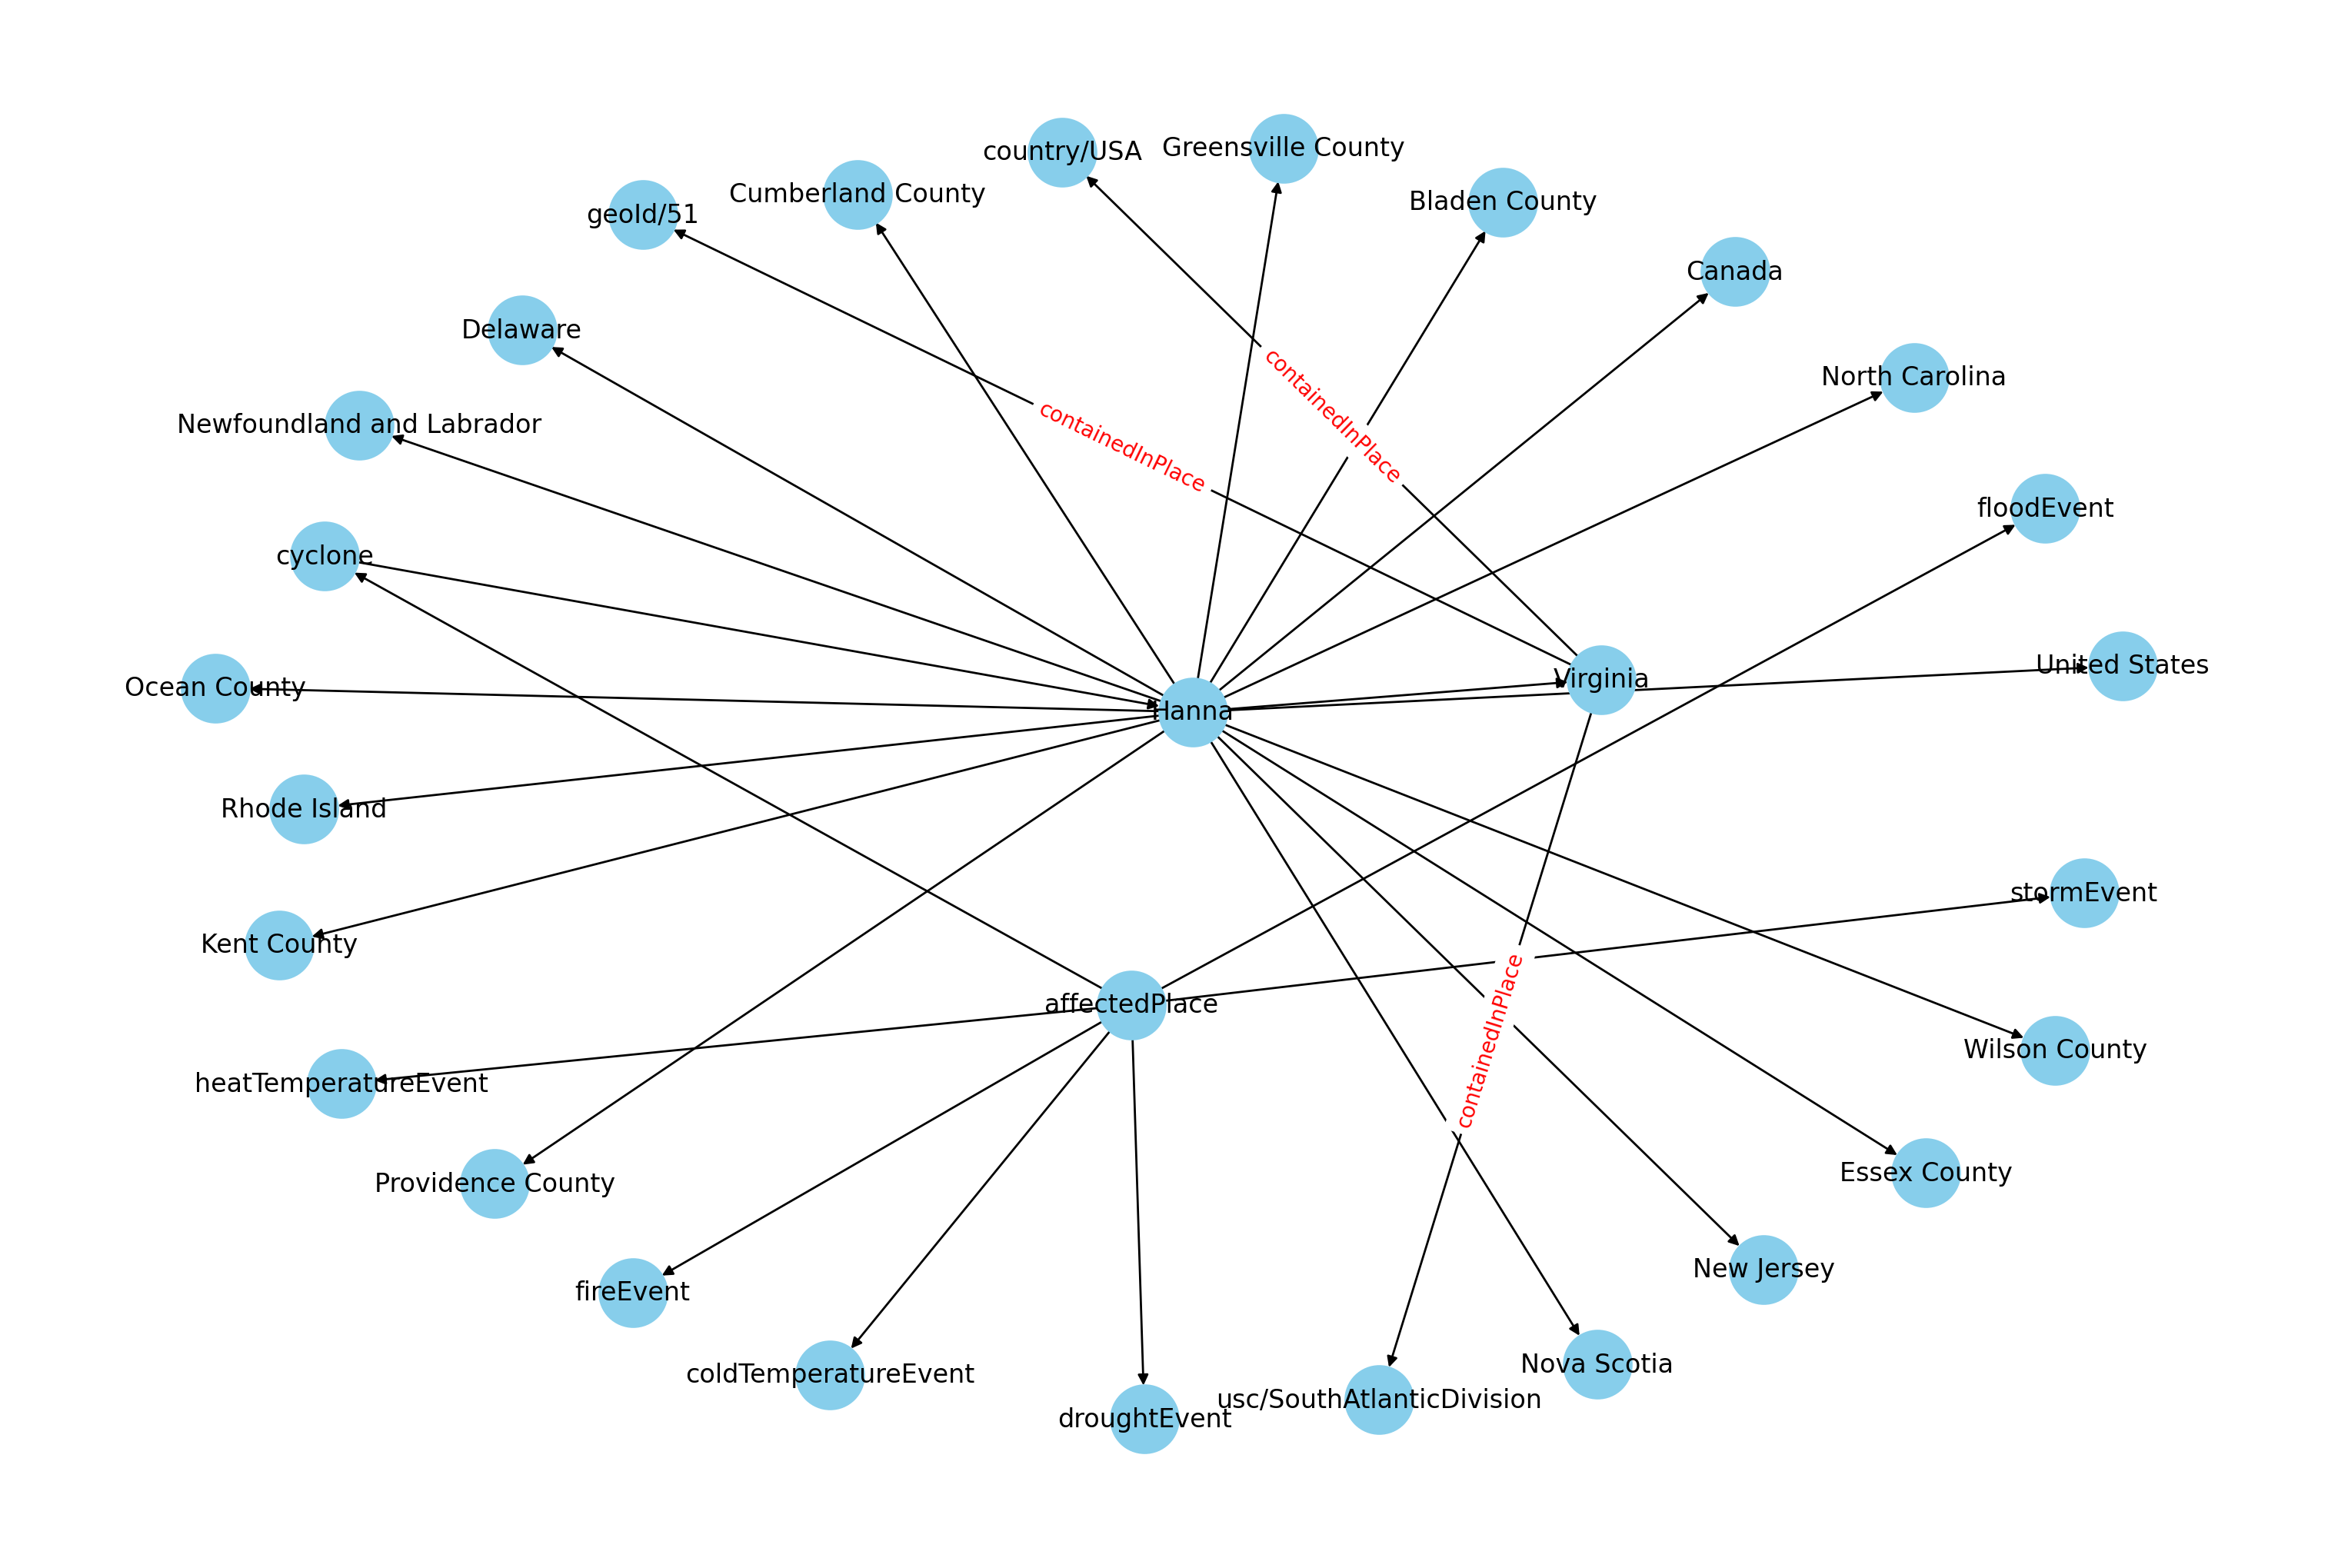

In [38]:
import datacommons as dc
import networkx as nx
import matplotlib.pyplot as plt

class StateKnowledgeGraph:
    def __init__(self, state_dcid):
        self.state_dcid = state_dcid
        self.state_name = self.get_state_name()
        self.triples = self.get_state_triples()
        self.graph = nx.DiGraph()

    def get_state_triples(self):
        """Retrieve triples for the given state."""
        return dc.get_triples([self.state_dcid])

    def get_state_name(self):
        """Retrieve the state name based on the DCID."""
        name = dc.get_property_values([self.state_dcid], prop='name')
        return name[self.state_dcid][0] if self.state_dcid in name else None

    def filter_predicates(self):
        """Filter to keep only relevant predicates."""
        relevant_predicates = {"affectedPlace", "containedInPlace", "location"}
        return [triple for triple in self.triples[self.state_dcid] if triple[1] in relevant_predicates]

    def count_event_classes(self):
        """Count event classes for affected places."""
        event_class_counts = {}
        for triple in self.triples[self.state_dcid]:
            if triple[1] == "affectedPlace":
                event_class = triple[0].split("/")[0]
                event_class_counts[event_class] = event_class_counts.get(event_class, 0) + 1
        return event_class_counts

    def filter_cyclone_triples(self):
        """Filter triples to include only those related to cyclones."""
        return [triple for triple in self.triples[self.state_dcid] if 'cyclone' in triple[0]]

    def get_cyclone_name(self, cyclone_dcid):
        """Get the name of a specific cyclone."""
        name = dc.get_property_values([cyclone_dcid], prop='name')
        return name[cyclone_dcid][0] if cyclone_dcid in name else None

    def get_affected_places(self, cyclone_dcid):
        """Get places affected by a specific cyclone."""
        triples_cyclone = dc.get_triples([cyclone_dcid])
        affected_by_cyclone = [triple for triple in triples_cyclone[cyclone_dcid] if triple[1] == "affectedPlace"]
        places_list = [triple[2] for triple in affected_by_cyclone]
        return dc.get_property_values(places_list, 'name')

    def draw_graph(self, cyclone_dcid=None):
        """Draw the knowledge graph."""
        # Add the initial state node
        self.graph.add_node(self.state_name)

        # Filter for relevant predicates
        filtered_triples = self.filter_predicates()

        # Add edges for each relevant predicate
        for triple in filtered_triples:
            self.graph.add_node(triple[2])
            self.graph.add_edge(self.state_name, triple[2], label=triple[1])

        # Add event class nodes connected to 'affectedPlace'
        event_class_counts = self.count_event_classes()
        for event_class in event_class_counts.keys():
            self.graph.add_node(event_class)
            self.graph.add_edge("affectedPlace", event_class)

        # Filter for cyclones and add cyclone-related nodes if cyclone_dcid is provided
        if cyclone_dcid:
            cyclone_name = self.get_cyclone_name(cyclone_dcid)
            self.graph.add_node(cyclone_name)
            self.graph.add_edge("cyclone", cyclone_name)

            # Add places affected by the cyclone
            affected_places = self.get_affected_places(cyclone_dcid)
            for place_dcid, place_name in affected_places.items():
                self.graph.add_node(place_name[0])
                self.graph.add_edge(cyclone_name, place_name[0])

        # Set the figure size to be larger for better readability
        plt.figure(figsize=(15, 10))

        # Draw the graph with adjusted parameters
        pos = nx.spring_layout(self.graph, k=3, iterations=100)  # Increase the k value for more space between nodes
        nx.draw(self.graph, pos, with_labels=True, arrows=True, node_size=1000, node_color="skyblue", font_size=12)
        edge_labels = nx.get_edge_attributes(self.graph, 'label')
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels, font_color='red', font_size=10)
        plt.show()

# Example usage:
state_kg = StateKnowledgeGraph("geoId/51")
state_kg.draw_graph(cyclone_dcid='cyclone/ibtracs_2008241N19303')


## 🧩 Wrapping Up: Building a State-Centric Interconnectivity Graph

In this final section, we've brought together everything we've learned to build a flexible, modular, and visually intuitive knowledge graph that represents how a U.S. state (e.g., Virginia) connects to real-world events and locations through the Data Commons Knowledge Graph.

---

### 🔧 What This Code Does

The class `StateKnowledgeGraph` is designed to:
- Query the **triples** associated with a given state.
- Filter for meaningful relationships like `affectedPlace`, `containedInPlace`, and `location`.
- Visualize how the state is connected to:
  - **Event classes** such as `fireEvent`, `stormEvent`, or `cyclone`.
  - Specific **cyclone names** and their **affected locations**.
  - Other **regions, counties, and identifiers** involved in the same event chains.

You can pass in any U.S. state using its DCID (e.g., `geoId/06` for California, `geoId/51` for Virginia), and optionally visualize relationships tied to specific cyclone events.

---

### 🧠 How to Read the Final Graph

Here's what you're looking at:

- **Center node:** Your chosen state (e.g., "Virginia")
- **Blue arrows and nodes:** Relationships between the state and connected locations or entities via `affectedPlace`, `containedInPlace`, or `location`.
- **Cyclone branch (if selected):**
  - A node labeled with the cyclone name (e.g., "Hanna")
  - Arrows pointing to all places affected by that cyclone

- **Red edge labels:** Relationship types (e.g., `affectedPlace`, `containedInPlace`)

---

### 🕸️ What This Graph Tells Us

This graph gives you a bird’s-eye view of **multi-hop interconnectivity**:
- Which **types of events** affected a state
- Which **regions share events**
- How **natural disasters ripple through** connected geographies

It also shows the **rich, layered structure** of the Data Commons knowledge graph — helping you "walk" from a single state to events, affected counties, and even abstract spatial identifiers like `s2CellId`.

---

### 🚀 Next Steps

- Try running the class with different state DCIDs (e.g., `geoId/12` for Florida)
- Explore cyclone paths and affected areas
- Use the `draw_graph()` method to plug in any node from the KG and visualize its relational web

This ends our graph-building section — you now have a working toolkit for **exploring interconnectivity at scale**!



# ✅ Summary: What We Learned

In this notebook, we explored how to use the **Google Data Commons Knowledge Graph** to analyze and visualize interconnectivity between places, events, and shared relationships.

Specifically, we learned how to:

- Use `get_triples()` and `get_property_values()` to access and interpret real-world relationships
- Filter and classify **predicates** like `affectedPlace`, `containedInPlace`, and `location`
- Group and count event types using custom logic (e.g., `fireEvent`, `cyclone`, `stormEvent`)
- Visualize multi-hop relationships using `networkx`:
  - State → Event Type → Specific Event → Affected Places
- Build a reusable class `StateKnowledgeGraph` to:
  - Dynamically fetch and organize triples
  - Visualize cyclone-specific impact
  - Scale to any U.S. state by DCID
- Enhance graphs with readable labels and hierarchical layering

---

## 🚀 Next Up: Apply Your Skills

Now that you've seen how to analyze **interconnected events** and **shared geographic relationships**, try using this approach to:

- Compare different states and event histories
- Expand from natural disasters to economic or demographic metadata
- Explore how the same regions are repeatedly affected by different types of events

---

### 📚 Previous Tutorials in the Series

### ✅ [Notebook 1: Knowledge Graph Basics](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/01_data_commons_basics.ipynb)
- Understand core concepts in graph-based data
- Use `get_triples()` and `networkx` to explore place-based relationships

### 📊 [Notebook 2: Environmental Data Exploration](https://colab.research.google.com/github/Nastiiasaenko/Data-Commons-/blob/main/02_environmental_exploration.ipynb)
- Retrieve CO₂ and methane emissions
- Build time series across states and sectors

---

> 💡 This notebook concludes the series — but it opens the door to **custom explorations** of the knowledge graph, using real data to uncover hidden patterns.

---
